In [6]:
import sys
sys.path.append(r"C:\Users\SUMANT\Desktop\youtube_etl_pipeline")
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine
from config import DB_CONFIG

engine = create_engine(
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

df = pd.read_sql("SELECT * FROM trending_videos", engine)
print(f"Total records: {len(df):,}")
print(f"Unique videos: {df['video_id'].nunique():,}")
print(f"Date range: {df['extracted_at'].min()} → {df['extracted_at'].max()}")


Total records: 383
Unique videos: 383
Date range: 2026-05-08 13:33:51.155965 → 2026-05-11 02:23:19.135676


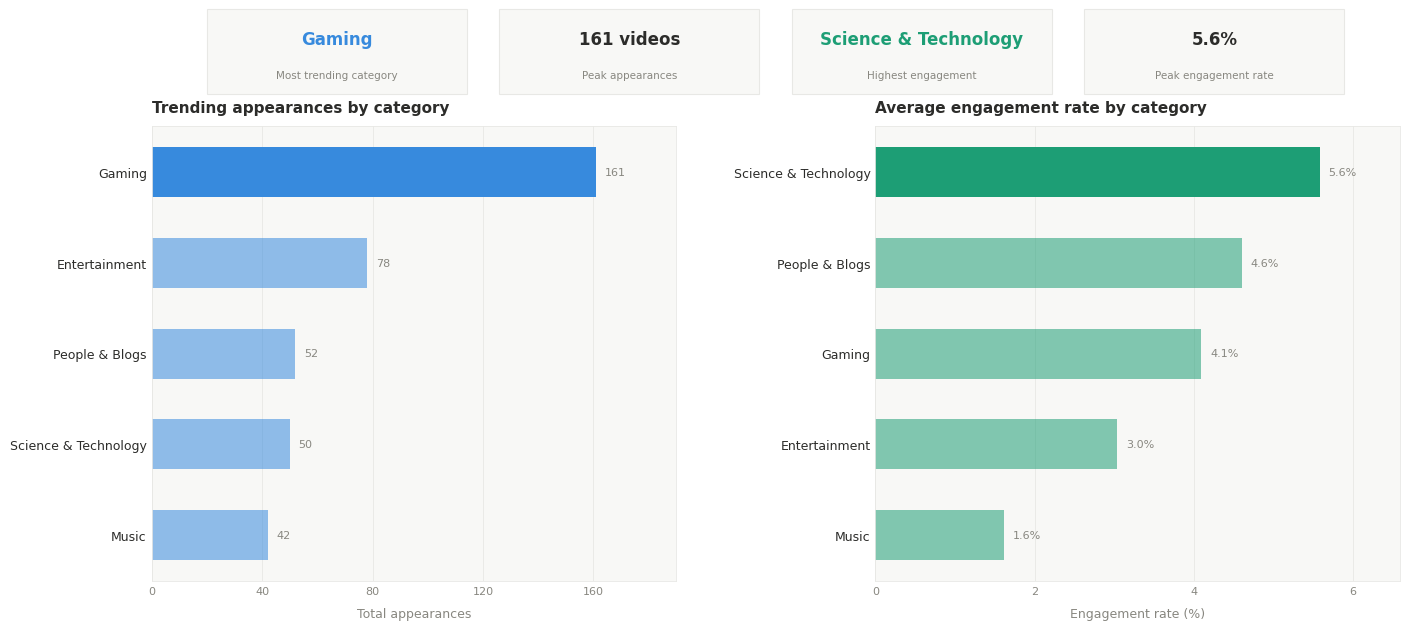

                      total_appearances   avg_views  avg_engagement  \
category_name                                                         
Gaming                              161   427770.40            4.09   
Entertainment                        78  5391731.40            3.04   
People & Blogs                       52   274676.85            4.60   
Science & Technology                 50   928087.82            5.58   
Music                                42  3617950.33            1.61   

                      avg_duration_mins  
category_name                            
Gaming                            85.29  
Entertainment                      0.80  
People & Blogs                    17.89  
Science & Technology               8.99  
Music                              4.59  


In [7]:
# ── Colors ────────────────────────────────────────────────────────
BLUE     = "#378ADD"
TEAL     = "#1D9E75"
BG       = "#FFFFFF"
PANEL_BG = "#F8F8F6"
GRID_CLR = "#E8E8E5"
TEXT_PRI = "#2C2C2A"
TEXT_SEC = "#888780"

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL_BG,
    "axes.edgecolor":     GRID_CLR,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "axes.grid":          True,
    "axes.grid.axis":     "x",
    "grid.color":         GRID_CLR,
    "grid.linewidth":     0.6,
    "xtick.color":        TEXT_SEC,
    "ytick.color":        TEXT_PRI,
    "xtick.labelsize":    8,
    "ytick.labelsize":    9,
    "xtick.major.size":   0,
    "ytick.major.size":   0,
    "text.color":         TEXT_PRI,
    "font.family":        "DejaVu Sans",
})

# ── Aggregate ─────────────────────────────────────────────────────
cat_stats = (df.groupby("category_name")
               .agg(
                   total_appearances = ("video_id",        "count"),
                   avg_views         = ("view_count",      "mean"),
                   avg_engagement    = ("engagement_rate", "mean"),
                   avg_duration_mins = ("duration_minutes","mean"),
               )
               .round(2)
               .sort_values("total_appearances", ascending=False))

# ── Derived KPIs ──────────────────────────────────────────────────
top_app_cat = cat_stats["total_appearances"].idxmax()
top_app_val = int(cat_stats["total_appearances"].max())
top_eng_cat = cat_stats["avg_engagement"].idxmax()
top_eng_val = cat_stats["avg_engagement"].max()

# ── Sort each series independently (ascending so top bar is last) ─
app_sorted = cat_stats["total_appearances"].sort_values(ascending=True)
eng_sorted = cat_stats["avg_engagement"].sort_values(ascending=True)

# ── Helpers ───────────────────────────────────────────────────────
def bar_colors(n, base_hex, alpha_rest=0.55):
    faded = base_hex + f"{int(alpha_rest * 255):02X}"
    colors = [faded] * n
    colors[-1] = base_hex          # top bar full opacity
    return colors

def draw_panel(ax, series, color, xlabel, title, fmt="{:.0f}"):
    n = len(series)
    bars = ax.barh(
        series.index, series.values,
        color=bar_colors(n, color),
        height=0.55, zorder=2
    )
    x_max = series.values.max()
    for bar, val in zip(bars, series.values):
        ax.text(
            bar.get_width() + x_max * 0.02,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(val),
            va="center", ha="left",
            fontsize=8, color=TEXT_SEC
        )
    ax.set_title(title, loc="left", pad=10,
                 fontsize=11, fontweight="bold", color=TEXT_PRI)
    ax.set_xlabel(xlabel, labelpad=8, fontsize=9, color=TEXT_SEC)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
    ax.set_xlim(0, x_max * 1.18)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(GRID_CLR)
        spine.set_linewidth(0.6)

# ── Figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(13, 6.5),
    gridspec_kw={"wspace": 0.38, "left": 0.02, "right": 0.98,
                 "top": 0.80, "bottom": 0.10}
)

# ── KPI cards ─────────────────────────────────────────────────────
cards = [
    (top_app_cat,            "Most trending category", BLUE),
    (f"{top_app_val} videos","Peak appearances",       TEXT_PRI),
    (top_eng_cat,            "Highest engagement",     TEAL),
    (f"{top_eng_val:.1f}%",  "Peak engagement rate",   TEXT_PRI),
]

card_w, card_h = 0.20, 0.13
card_gap = 0.025
x0 = (1 - (4 * card_w + 3 * card_gap)) / 2

for i, (val, label, color) in enumerate(cards):
    cx = x0 + i * (card_w + card_gap)
    fig.add_artist(plt.Rectangle(
        (cx, 0.85), card_w, card_h,
        transform=fig.transFigure,
        facecolor=PANEL_BG, edgecolor=GRID_CLR,
        linewidth=0.8, clip_on=False, zorder=3, figure=fig
    ))
    fig.text(cx + card_w / 2, 0.85 + card_h * 0.65, val,
             ha="center", va="center",
             fontsize=12, fontweight="bold", color=color,
             transform=fig.transFigure, zorder=4)
    fig.text(cx + card_w / 2, 0.85 + card_h * 0.22, label,
             ha="center", va="center",
             fontsize=7.5, color=TEXT_SEC,
             transform=fig.transFigure, zorder=4)

# ── Charts ────────────────────────────────────────────────────────
draw_panel(axes[0], app_sorted,
           BLUE, "Total appearances",
           "Trending appearances by category")

draw_panel(axes[1], eng_sorted,
           TEAL, "Engagement rate (%)",
           "Average engagement rate by category",
           fmt="{:.1f}%")

# ── Save ──────────────────────────────────────────────────────────
plt.savefig("category_analysis.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
print(cat_stats)

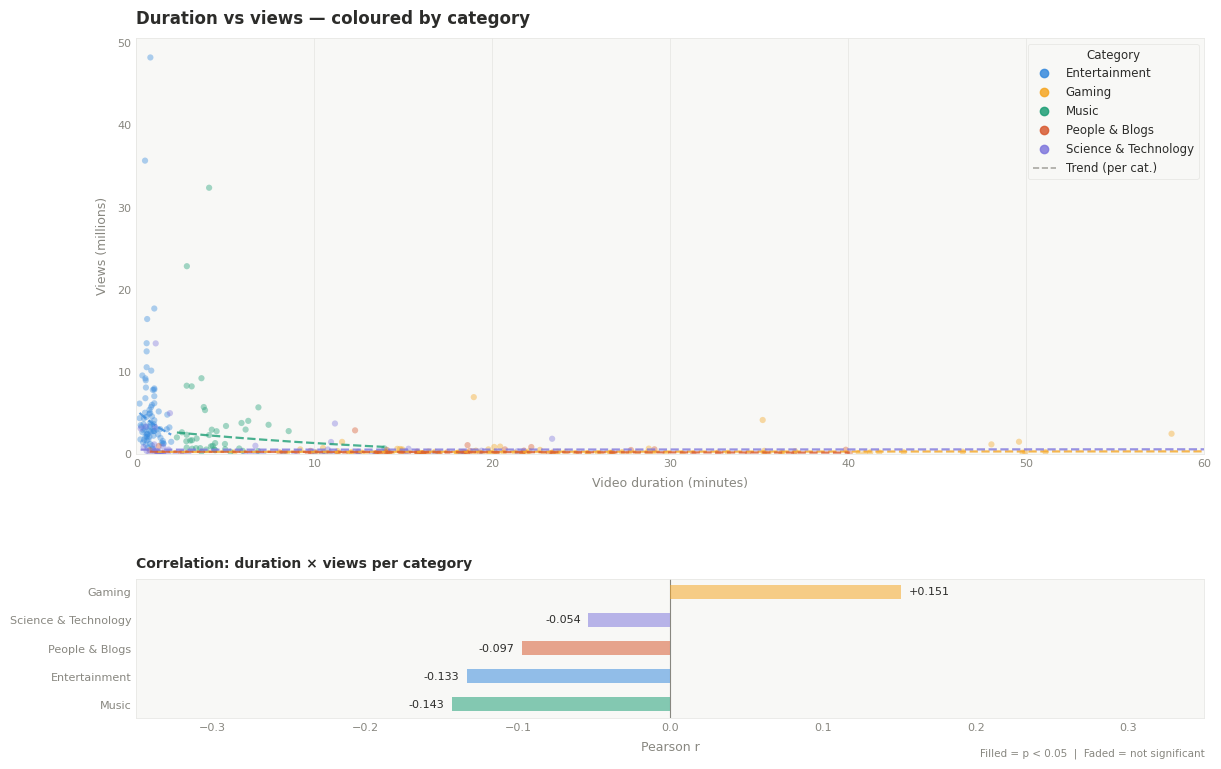

In [8]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import pearsonr

# ── Colors ────────────────────────────────────────────────────────
CAT_COLORS = {
    "Entertainment":        "#378ADD",
    "Gaming":               "#F5A623",
    "Music":                "#1D9E75",
    "People & Blogs":       "#D85A30",
    "Science & Technology": "#7F77DD",
}

BG       = "#FFFFFF"
PANEL_BG = "#F8F8F6"
GRID_CLR = "#E8E8E5"
TEXT_PRI = "#2C2C2A"
TEXT_SEC = "#888780"

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL_BG,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "axes.grid":          True,
    "grid.color":         GRID_CLR,
    "grid.linewidth":     0.6,
    "xtick.color":        TEXT_SEC,
    "ytick.color":        TEXT_SEC,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.size":   0,
    "ytick.major.size":   0,
    "font.family":        "DejaVu Sans",
})

# ── Pre-compute correlations ──────────────────────────────────────
corr_data = {}
for cat, grp in df.groupby("category_name"):
    if len(grp) > 5:
        r, p = pearsonr(grp["duration_minutes"], grp["view_count"])
        corr_data[cat] = (r, p)

# ── Layout: scatter (top) + corr bar chart (bottom) ──────────────
fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(
    2, 1, height_ratios=[3, 1],
    hspace=0.45,
    left=0.08, right=0.97,
    top=0.93, bottom=0.08
)
ax_scatter = fig.add_subplot(gs[0])
ax_corr    = fig.add_subplot(gs[1])

# ══ SCATTER ══════════════════════════════════════════════════════
for cat, grp in df.groupby("category_name"):
    color = CAT_COLORS.get(cat, "#888780")
    x = grp["duration_minutes"].values
    y = grp["view_count"].values / 1e6

    ax_scatter.scatter(x, y,
                       color=color, alpha=0.40, s=20,
                       edgecolors="none", zorder=2)

    mask = (x > 0) & (y > 0)
    if mask.sum() > 5:
        z     = np.polyfit(x[mask], np.log1p(y[mask]), 1)
        xline = np.linspace(x[mask].min(), x[mask].max(), 300)
        ax_scatter.plot(xline, np.expm1(np.polyval(z, xline)),
                        color=color, linewidth=1.6,
                        alpha=0.80, linestyle="--", zorder=3)

ax_scatter.set_xlim(0, 60)
ax_scatter.set_ylim(bottom=0)
ax_scatter.set_xlabel("Video duration (minutes)", labelpad=6,
                       fontsize=9, color=TEXT_SEC)
ax_scatter.set_ylabel("Views (millions)", labelpad=6,
                       fontsize=9, color=TEXT_SEC)
ax_scatter.set_title("Duration vs views — coloured by category",
                      loc="left", pad=10,
                      fontsize=12, fontweight="bold", color=TEXT_PRI)

for spine in ax_scatter.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRID_CLR)
    spine.set_linewidth(0.6)

# Legend
scatter_handles = [
    mlines.Line2D([], [], marker="o", linestyle="none",
                  color=CAT_COLORS.get(cat, "#888780"),
                  markersize=6, alpha=0.85, label=cat)
    for cat in sorted(CAT_COLORS)
]
trend_handle = mlines.Line2D([], [], linestyle="--", color=TEXT_SEC,
                              linewidth=1.2, alpha=0.7,
                              label="Trend (per cat.)")
legend = ax_scatter.legend(
    handles=scatter_handles + [trend_handle],
    loc="upper right",
    frameon=True, framealpha=1,
    edgecolor=GRID_CLR,
    fontsize=8.5,
    title="Category", title_fontsize=8.5,
)
legend.get_frame().set_linewidth(0.6)

# ══ CORRELATION BAR CHART ════════════════════════════════════════
cats_sorted = sorted(corr_data, key=lambda c: corr_data[c][0])
r_vals      = [corr_data[c][0] for c in cats_sorted]
colors_bar  = [
    CAT_COLORS.get(c, "#888780") + ("FF" if corr_data[c][1] < 0.05 else "88")
    for c in cats_sorted
]

bars = ax_corr.barh(
    cats_sorted, r_vals,
    color=colors_bar, height=0.5,
    zorder=2
)

# Value labels
for bar, r in zip(bars, r_vals):
    xpos  = r + (0.005 if r >= 0 else -0.005)
    ha    = "left" if r >= 0 else "right"
    ax_corr.text(xpos, bar.get_y() + bar.get_height() / 2,
                 f"{r:+.3f}", va="center", ha=ha,
                 fontsize=8, color=TEXT_PRI)

# Zero line
ax_corr.axvline(0, color=TEXT_SEC, linewidth=0.8, zorder=1)

ax_corr.set_xlabel("Pearson r", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_corr.set_title("Correlation: duration × views per category",
                   loc="left", pad=8,
                   fontsize=10, fontweight="bold", color=TEXT_PRI)
ax_corr.set_xlim(-0.35, 0.35)
ax_corr.grid(axis="x")

# Significance note
sig_note = "Filled = p < 0.05  |  Faded = not significant"
ax_corr.text(1.0, -0.28, sig_note,
             transform=ax_corr.transAxes,
             fontsize=7.5, color=TEXT_SEC, ha="right")

for spine in ax_corr.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRID_CLR)
    spine.set_linewidth(0.6)

# ── Save ──────────────────────────────────────────────────────────
plt.savefig("duration_vs_views.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

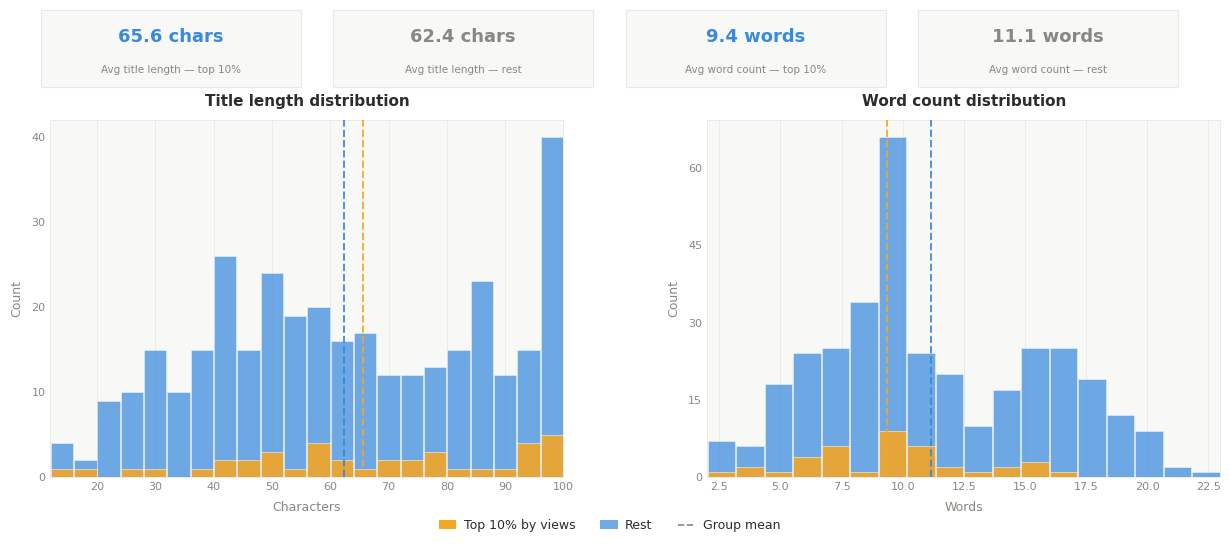

In [10]:

# ── Colors ────────────────────────────────────────────────────────
GOLD      = "#F5A623"
BLUE      = "#378ADD"
BG        = "#FFFFFF"
PANEL_BG  = "#F8F8F6"
GRID_CLR  = "#E8E8E5"
TEXT_PRI  = "#2C2C2A"
TEXT_SEC  = "#888780"

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL_BG,
    "axes.edgecolor":     GRID_CLR,
    "axes.labelcolor":    TEXT_SEC,
    "axes.titlecolor":    TEXT_PRI,
    "axes.titlesize":     11,
    "axes.titleweight":   "bold",
    "axes.titlepad":      12,
    "axes.labelsize":     9,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "axes.grid":          True,
    "grid.color":         GRID_CLR,
    "grid.linewidth":     0.6,
    "grid.alpha":         1.0,
    "xtick.color":        TEXT_SEC,
    "ytick.color":        TEXT_SEC,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.size":   0,
    "ytick.major.size":   0,
    "text.color":         TEXT_PRI,
    "font.family":        "DejaVu Sans",
})

# ── Stat cards (printed as a text summary above the figure) ───────
top_10pct = df[df["view_count"] >= df["view_count"].quantile(0.90)]
rest      = df[df["view_count"] <  df["view_count"].quantile(0.90)]
top_avg_len  = top_10pct["title_length"].mean()
rest_avg_len = rest["title_length"].mean()
top_avg_wc   = top_10pct["title_word_count"].mean()
rest_avg_wc  = rest["title_word_count"].mean()

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5.5), facecolor=BG)

# Metric card row at top using text annotations on fig
cards = [
    (f"{top_avg_len:.1f} chars", "Avg title length — top 10%",  BLUE),
    (f"{rest_avg_len:.1f} chars", "Avg title length — rest",     TEXT_SEC),
    (f"{top_avg_wc:.1f} words",  "Avg word count — top 10%",    BLUE),
    (f"{rest_avg_wc:.1f} words", "Avg word count — rest",        TEXT_SEC),
]
card_w, card_h = 0.20, 0.14
card_gap = 0.025
total_w  = 4 * card_w + 3 * card_gap
x0       = (1 - total_w) / 2

for i, (val, label, color) in enumerate(cards):
    cx = x0 + i * (card_w + card_gap)
    rect = plt.Rectangle((cx, 0.84), card_w, card_h,
                          transform=fig.transFigure,
                          facecolor=PANEL_BG, edgecolor=GRID_CLR,
                          linewidth=0.8, clip_on=False,
                          zorder=3, figure=fig)
    fig.add_artist(rect)
    fig.text(cx + card_w / 2, 0.84 + card_h * 0.65, val,
             ha="center", va="center",
             fontsize=13, fontweight="bold", color=color,
             transform=fig.transFigure, zorder=4)
    fig.text(cx + card_w / 2, 0.84 + card_h * 0.22, label,
             ha="center", va="center",
             fontsize=7.5, color=TEXT_SEC,
             transform=fig.transFigure, zorder=4)

# ── Chart panels ──────────────────────────────────────────────────
axes = fig.subplots(1, 2, gridspec_kw={"wspace": 0.28,
                                        "top": 0.78,
                                        "bottom": 0.13,
                                        "left": 0.07,
                                        "right": 0.97})

def draw_panel(ax, top_data, rest_data, bins, xlabel, title):
    # Shared bin edges
    combined  = np.concatenate([top_data, rest_data])
    bin_edges = np.linspace(combined.min(), combined.max(), bins + 1)

    # Rest (background)
    ax.hist(rest_data, bins=bin_edges,
            color=BLUE, alpha=0.72, zorder=2,
            edgecolor=BG, linewidth=0.4, rwidth=0.96)

    # Top 10% (foreground)
    ax.hist(top_data, bins=bin_edges,
            color=GOLD, alpha=0.88, zorder=3,
            edgecolor=BG, linewidth=0.4, rwidth=0.96)

    # Mean lines
    for mean_val, clr in [(rest_data.mean(), BLUE),
                          (top_data.mean(),  GOLD)]:
        ax.axvline(mean_val, color=clr, linewidth=1.4,
                   linestyle="--", alpha=0.9, zorder=4)

    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel("Count", labelpad=6)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
    ax.set_xlim(bin_edges[0], bin_edges[-1])

    # Subtle border around panel
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(GRID_CLR)
        spine.set_linewidth(0.6)

draw_panel(axes[0],
           top_10pct["title_length"].values,
           rest["title_length"].values,
           bins=22,
           xlabel="Characters",
           title="Title length distribution")

draw_panel(axes[1],
           top_10pct["title_word_count"].values,
           rest["title_word_count"].values,
           bins=18,
           xlabel="Words",
           title="Word count distribution")

# ── Shared legend ─────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=GOLD, edgecolor="none",          label="Top 10% by views"),
    mpatches.Patch(facecolor=BLUE, edgecolor="none", alpha=0.72, label="Rest"),
    plt.Line2D([0], [0], color=TEXT_SEC, linewidth=1.2,
               linestyle="--", label="Group mean"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.01),
    frameon=False,
    fontsize=9,
    handlelength=1.4,
    handletextpad=0.6,
    columnspacing=2.0,
)

plt.savefig("title_patterns.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

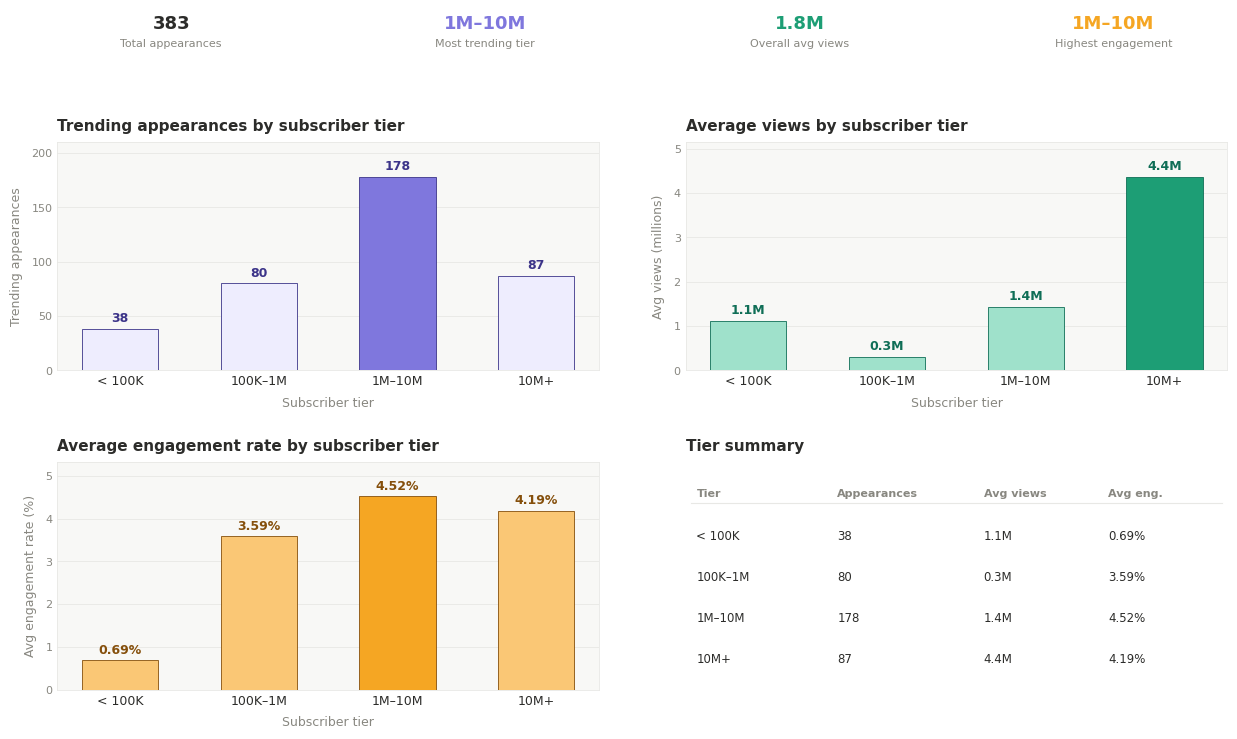

                 video_count   avg_views  avg_engagement
subscriber_tier                                         
< 100K                    38  1112162.03            0.69
100K–1M                   80   297493.61            3.59
1M–10M                   178  1439030.02            4.52
10M+                      87  4366190.76            4.19


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np

# ── Colors ────────────────────────────────────────────────────────
PURPLE   = "#7F77DD"
PURPLE_L = "#EEEDFE"
PURPLE_D = "#3C3489"
TEAL     = "#1D9E75"
GOLD     = "#F5A623"
BG       = "#FFFFFF"
PANEL_BG = "#F8F8F6"
GRID_CLR = "#E8E8E5"
TEXT_PRI = "#2C2C2A"
TEXT_SEC = "#888780"

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL_BG,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.color":         GRID_CLR,
    "grid.linewidth":     0.6,
    "xtick.color":        TEXT_PRI,
    "ytick.color":        TEXT_SEC,
    "xtick.labelsize":    9,
    "ytick.labelsize":    8,
    "xtick.major.size":   0,
    "ytick.major.size":   0,
    "font.family":        "DejaVu Sans",
})

# ── Data ──────────────────────────────────────────────────────────
ch_df  = pd.read_sql("SELECT * FROM channel_stats", engine)
merged = df.merge(ch_df, on="channel_id", how="left")

bins   = [0, 100_000, 1_000_000, 10_000_000, float("inf")]
labels = ["< 100K", "100K–1M", "1M–10M", "10M+"]
merged["subscriber_tier"] = pd.cut(
    merged["subscriber_count"], bins=bins, labels=labels
)

tier_stats = (merged.groupby("subscriber_tier", observed=True)
              .agg(video_count     = ("video_id",        "count"),
                   avg_views       = ("view_count",      "mean"),
                   avg_engagement  = ("engagement_rate", "mean"))
              .round(2))

tiers      = tier_stats.index.astype(str).tolist()
counts     = tier_stats["video_count"].values
avg_views  = tier_stats["avg_views"].values / 1e6
avg_eng    = tier_stats["avg_engagement"].values
x          = np.arange(len(tiers))

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
gs  = gridspec.GridSpec(
    3, 4,
    height_ratios=[0.18, 1, 1],
    hspace=0.55, wspace=0.38,
    left=0.07, right=0.97,
    top=0.95, bottom=0.10
)

# ── KPI cards ─────────────────────────────────────────────────────
top_tier     = tiers[np.argmax(counts)]
top_eng_tier = tiers[np.argmax(avg_eng)]
kpis = [
    (f"{counts.sum():,}",         "Total appearances",    TEXT_PRI),
    (top_tier,                    "Most trending tier",   PURPLE),
    (f"{avg_views.mean():.1f}M",  "Overall avg views",   TEAL),
    (top_eng_tier,                "Highest engagement",   GOLD),
]
for i, (val, label, color) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor(PANEL_BG)
    ax_k.set_axis_off()
    for spine in ax_k.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(GRID_CLR)
        spine.set_linewidth(0.8)
    ax_k.text(0.5, 0.65, val, ha="center", va="center",
              transform=ax_k.transAxes,
              fontsize=13, fontweight="bold", color=color)
    ax_k.text(0.5, 0.18, label, ha="center", va="center",
              transform=ax_k.transAxes,
              fontsize=8, color=TEXT_SEC)

# ── Bar chart: trending appearances (row 1, left 2 cols) ──────────
ax_bar = fig.add_subplot(gs[1, :2])

bar_colors = [PURPLE if c == counts.max() else PURPLE_L for c in counts]
bars = ax_bar.bar(x, counts,
                  color=bar_colors, edgecolor=PURPLE_D,
                  linewidth=0.6, width=0.55, zorder=2)

for bar, val in zip(bars, counts):
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts.max() * 0.02,
                str(val), ha="center", va="bottom",
                fontsize=9, fontweight="bold",
                color=PURPLE_D)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(tiers)
ax_bar.set_xlabel("Subscriber tier", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_bar.set_ylabel("Trending appearances", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_bar.set_title("Trending appearances by subscriber tier",
                  loc="left", pad=8,
                  fontsize=11, fontweight="bold", color=TEXT_PRI)
ax_bar.set_ylim(0, counts.max() * 1.18)
ax_bar.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
for spine in ax_bar.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRID_CLR)
    spine.set_linewidth(0.6)

# ── Bar chart: avg views (row 1, right 2 cols) ────────────────────
ax_views = fig.add_subplot(gs[1, 2:])

view_colors = [TEAL if v == avg_views.max() else "#9FE1CB" for v in avg_views]
bars_v = ax_views.bar(x, avg_views,
                      color=view_colors, edgecolor="#0F6E56",
                      linewidth=0.6, width=0.55, zorder=2)

for bar, val in zip(bars_v, avg_views):
    ax_views.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + avg_views.max() * 0.02,
                  f"{val:.1f}M", ha="center", va="bottom",
                  fontsize=9, fontweight="bold", color="#0F6E56")

ax_views.set_xticks(x)
ax_views.set_xticklabels(tiers)
ax_views.set_xlabel("Subscriber tier", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_views.set_ylabel("Avg views (millions)", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_views.set_title("Average views by subscriber tier",
                    loc="left", pad=8,
                    fontsize=11, fontweight="bold", color=TEXT_PRI)
ax_views.set_ylim(0, avg_views.max() * 1.18)
for spine in ax_views.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRID_CLR)
    spine.set_linewidth(0.6)

# ── Bar chart: avg engagement (row 2, left 2 cols) ────────────────
ax_eng = fig.add_subplot(gs[2, :2])

eng_colors = [GOLD if e == avg_eng.max() else "#FAC775" for e in avg_eng]
bars_e = ax_eng.bar(x, avg_eng,
                    color=eng_colors, edgecolor="#854F0B",
                    linewidth=0.6, width=0.55, zorder=2)

for bar, val in zip(bars_e, avg_eng):
    ax_eng.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + avg_eng.max() * 0.02,
                f"{val:.2f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="#854F0B")

ax_eng.set_xticks(x)
ax_eng.set_xticklabels(tiers)
ax_eng.set_xlabel("Subscriber tier", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_eng.set_ylabel("Avg engagement rate (%)", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_eng.set_title("Average engagement rate by subscriber tier",
                  loc="left", pad=8,
                  fontsize=11, fontweight="bold", color=TEXT_PRI)
ax_eng.set_ylim(0, avg_eng.max() * 1.18)
for spine in ax_eng.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRID_CLR)
    spine.set_linewidth(0.6)

# ── Summary table (row 2, right 2 cols) ───────────────────────────
ax_tbl = fig.add_subplot(gs[2, 2:])
ax_tbl.set_facecolor(PANEL_BG)
ax_tbl.set_axis_off()

ax_tbl.set_title("Tier summary", loc="left", pad=8,
                  fontsize=11, fontweight="bold", color=TEXT_PRI)

col_headers = ["Tier", "Appearances", "Avg views", "Avg eng."]
rows        = list(zip(
    tiers,
    [str(c) for c in counts],
    [f"{v:.1f}M" for v in avg_views],
    [f"{e:.2f}%" for e in avg_eng],
))

col_x = [0.02, 0.28, 0.55, 0.78]
header_y = 0.88

for cx, hdr in zip(col_x, col_headers):
    ax_tbl.text(cx, header_y, hdr,
                transform=ax_tbl.transAxes,
                fontsize=8, fontweight="bold", color=TEXT_SEC, va="top")

line = Line2D([0.01, 0.99], [0.82, 0.82],
              transform=ax_tbl.transAxes,
              color=GRID_CLR, linewidth=0.8)
ax_tbl.add_artist(line)

row_y = 0.70
for row in rows:
    for cx, cell in zip(col_x, row):
        ax_tbl.text(cx, row_y, cell,
                    transform=ax_tbl.transAxes,
                    fontsize=8.5, color=TEXT_PRI, va="top")
    row_y -= 0.18

# ── Save ──────────────────────────────────────────────────────────
plt.savefig("channel_size_analysis.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
print(tier_stats)

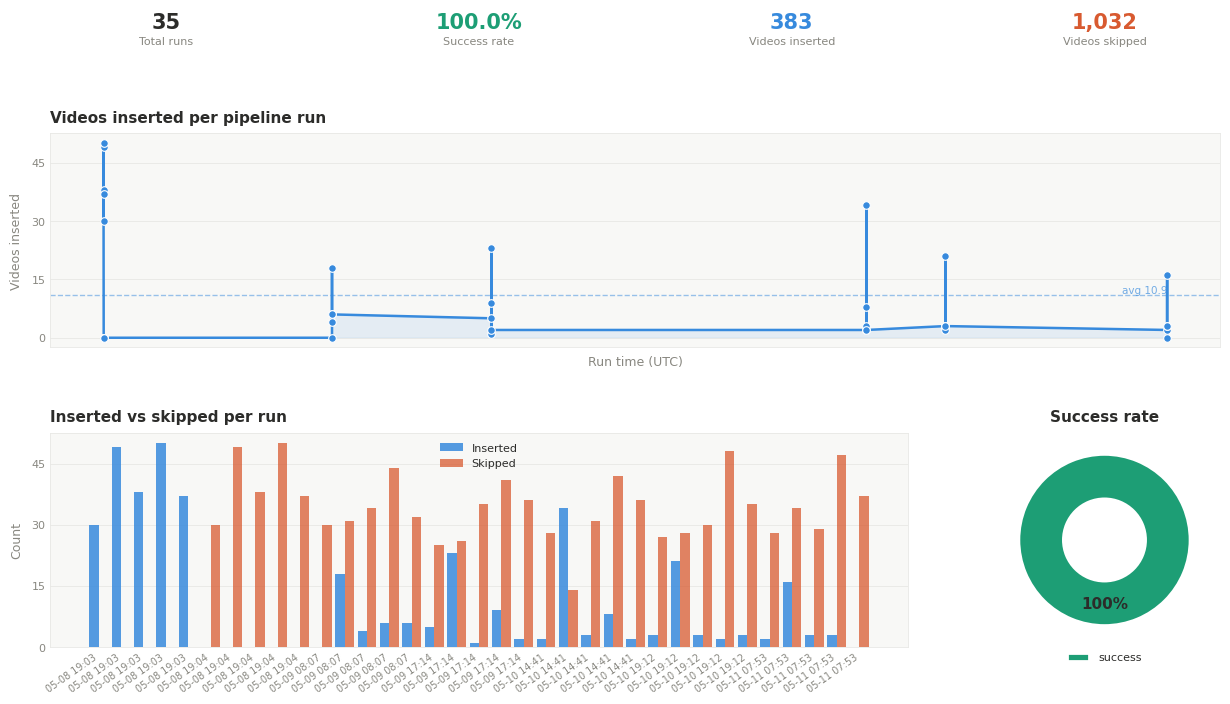

In [14]:
# ── Colors ────────────────────────────────────────────────────────
BLUE     = "#378ADD"
TEAL     = "#1D9E75"
CORAL    = "#D85A30"
BG       = "#FFFFFF"
PANEL_BG = "#F8F8F6"
GRID_CLR = "#E8E8E5"
TEXT_PRI = "#2C2C2A"
TEXT_SEC = "#888780"

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL_BG,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "axes.grid":          True,
    "grid.color":         GRID_CLR,
    "grid.linewidth":     0.6,
    "xtick.color":        TEXT_SEC,
    "ytick.color":        TEXT_SEC,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.size":   0,
    "ytick.major.size":   0,
    "font.family":        "DejaVu Sans",
})

# ── KPIs ──────────────────────────────────────────────────────────
runs = pd.read_sql(
    "SELECT * FROM pipeline_runs ORDER BY run_at", engine
)
total_runs      = len(runs)
success_rate    = (runs["status"] == "success").mean()
total_inserted  = runs["videos_inserted"].sum()
total_skipped   = runs["videos_skipped"].sum()
avg_inserted    = runs["videos_inserted"].mean()

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 7.5))
gs  = gridspec.GridSpec(
    3, 4,
    height_ratios=[0.18, 1, 1],
    hspace=0.55, wspace=0.35,
    left=0.07, right=0.97,
    top=0.95, bottom=0.10
)

# ── KPI cards (row 0) ─────────────────────────────────────────────
kpis = [
    (f"{total_runs}",           "Total runs",          TEXT_PRI),
    (f"{success_rate:.1%}",     "Success rate",        TEAL),
    (f"{total_inserted:,}",     "Videos inserted",     BLUE),
    (f"{total_skipped:,}",      "Videos skipped",      CORAL),
]
for i, (val, label, color) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor(PANEL_BG)
    ax_k.set_axis_off()
    for spine in ax_k.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(GRID_CLR)
        spine.set_linewidth(0.8)
    ax_k.text(0.5, 0.65, val, ha="center", va="center",
              transform=ax_k.transAxes,
              fontsize=15, fontweight="bold", color=color)
    ax_k.text(0.5, 0.18, label, ha="center", va="center",
              transform=ax_k.transAxes,
              fontsize=8, color=TEXT_SEC)

# ── Line chart: videos inserted (row 1, full width) ───────────────
ax_line = fig.add_subplot(gs[1, :])

# Fill under line
ax_line.fill_between(runs["run_at"], runs["videos_inserted"],
                     alpha=0.10, color=BLUE, zorder=1)

# Line + markers
ax_line.plot(runs["run_at"], runs["videos_inserted"],
             color=BLUE, linewidth=1.8, zorder=3)
ax_line.scatter(runs["run_at"], runs["videos_inserted"],
                color=BLUE, s=30, zorder=4, edgecolors=BG, linewidths=0.8)

# Flag failed runs in red
failed = runs[runs["status"] != "success"]
if not failed.empty:
    ax_line.scatter(failed["run_at"], failed["videos_inserted"],
                    color=CORAL, s=50, zorder=5,
                    edgecolors=BG, linewidths=0.8,
                    label="Failed run")
    ax_line.legend(fontsize=8, frameon=False)

# Average line
ax_line.axhline(avg_inserted, color=BLUE, linewidth=1.0,
                linestyle="--", alpha=0.5)
ax_line.text(runs["run_at"].iloc[-1], avg_inserted + 0.5,
             f"avg {avg_inserted:.1f}", fontsize=7.5,
             color=BLUE, alpha=0.7, ha="right")

ax_line.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax_line.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=30, ha="right")
ax_line.set_xlabel("Run time (UTC)", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_line.set_ylabel("Videos inserted", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_line.set_title("Videos inserted per pipeline run",
                   loc="left", pad=8,
                   fontsize=11, fontweight="bold", color=TEXT_PRI)
ax_line.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
for spine in ax_line.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRID_CLR)
    spine.set_linewidth(0.6)

# ── Bar chart: inserted vs skipped per run (row 2, left 3 cols) ───
ax_bar = fig.add_subplot(gs[2, :3])

x      = np.arange(len(runs))
width  = 0.42
labels = runs["run_at"].dt.strftime("%m-%d %H:%M")

ax_bar.bar(x - width/2, runs["videos_inserted"],
           width=width, color=BLUE, alpha=0.85,
           label="Inserted", zorder=2)
ax_bar.bar(x + width/2, runs["videos_skipped"],
           width=width, color=CORAL, alpha=0.75,
           label="Skipped", zorder=2)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels, rotation=35, ha="right", fontsize=7)
ax_bar.set_ylabel("Count", labelpad=6, fontsize=9, color=TEXT_SEC)
ax_bar.set_title("Inserted vs skipped per run",
                  loc="left", pad=8,
                  fontsize=11, fontweight="bold", color=TEXT_PRI)
ax_bar.legend(fontsize=8, frameon=False)
ax_bar.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
for spine in ax_bar.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRID_CLR)
    spine.set_linewidth(0.6)

# ── Donut chart: success rate (row 2, right col) ──────────────────
ax_donut = fig.add_subplot(gs[2, 3])
ax_donut.set_facecolor(BG)

status_counts = runs["status"].value_counts()
donut_colors  = [TEAL if s == "success" else CORAL
                 for s in status_counts.index]

wedges, texts, autotexts = ax_donut.pie(
    status_counts,
    labels=None,
    colors=donut_colors,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"width": 0.52, "edgecolor": BG, "linewidth": 2},
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color(TEXT_PRI)

ax_donut.legend(
    wedges, status_counts.index,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    fontsize=8, frameon=False,
    ncol=len(status_counts)
)
ax_donut.set_title("Success rate",
                    pad=8, fontsize=11,
                    fontweight="bold", color=TEXT_PRI)

# ── Save ──────────────────────────────────────────────────────────
plt.savefig("pipeline_health.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()